# Summary of Key Findings

## 1. Data Quality and Structure
- **Dataset**: 1,500 participants, 35 variables, cross-sectional design.
  No missing values and no duplicate rows confirmed programmatically.
- **Variable types**: Continuous psychological scores (YSQ-S3 schemas, DERS,
  PSS, MPSS), anthropometric measures (BMI, WC), behavioural indices (IPAQ,
  UDI), and categorical grouping variables (sex, age_group, BMI_group, group).
- **Participant grouping**: The `group` variable distinguishes community from
  medical recruits. The medical group shows systematically elevated scores on
  maladaptive psychological traits, consistent with clinical expectation.

## 2. Distribution Patterns
- **BMI**: Mean ≈ 25.9, right-skewed a tail of higher-weight participants
  reflects the deliberate inclusion of overweight/obese individuals.
- **Psychological scales**: DERS_Total and PSS_10 show wide between-person
  variability. Extreme scores were retained rather than removed, as they
  represent genuine clinical cases rather than measurement error.
- **Eating behaviour targets**: QERB_EmotionalOvereating shows the strongest
  association with psychological predictors and was selected as the primary
  modelling target on both theoretical and data-driven grounds.

## 3. Key Correlations
- **Emotional overeating** correlates most strongly with BMI_group (r = 0.82),
  DERS_Total (r = 0.62), Stress_x_EmotionReg (r = 0.67), and UDI (r = 0.61),
  suggesting that weight status, emotion regulation capacity, stress burden,
  and dietary quality are the dominant co-occurring factors.
- **Habitual overeating** associates more strongly with anthropometric
  variables (BMI, WC), while emotional overeating associates more strongly
  with psychological variables confirming that these are meaningfully
  distinct behavioural phenotypes requiring separate explanatory models.
- **Schema intercorrelations**: All 18 YSQ-S3 subscales are highly
  intercorrelated (VIF 40–78), reflecting shared variance from a common
  latent vulnerability factor rather than measurement redundancy.

## 4. Feature Engineering
- **Stress_x_EmotionReg** (PSS_10 × DERS_Total): An interaction term
  operationalising the hypothesis that stress only translates into maladaptive
  eating when paired with poor regulatory capacity. This term achieved r = 0.67
  with the target stronger than either constituent variable alone validating
  the interaction rationale.
- **Age_Category_Bin**: Created for visualisation only; excluded from all
  models. Continuous age_years retained where relevant.

## 5. Feature Selection
- Correlation filtering (|r| > 0.10) retained 30 of 31 features.
- RFE with a linear base estimator selected 10 features as a domain heuristic,
  identifying a mix of schema features (DefectivenessShame, Enmeshment,
  SelfSacrifice, NegativityPessimism, UnrelentingStandards, Entitlement) and
  non-schema variables (BMI_group, age_group, UDI, sex).
- **Critical design decision**: features were NOT dropped to resolve
  multicollinearity. Dropping correlated schema features discards shared
  signal and worsens test RMSE. Collinearity was instead handled
  architecturally in the modelling stage (PCA + Ridge).

## 6. Modelling Pipeline
- **Dual-path architecture**: linear models (Ridge, Lasso) trained on raw
  features; tree models trained on PCA-compressed schema features. This
  prevents collinearity-driven overfitting in trees without discarding signal.
- **PCA**: Applied to the 6 schema features selected by RFE, compressing them
  into 3 orthogonal principal components retaining ~73% of schema variance.
  Schema_PC1 captures generalised schema burden; PC2 and PC3 capture specific
  schema profile contrasts.
- **Model comparison** (Repeated 5×3 CV): Tree models outperformed linear
  models substantially (XGBoost CV RMSE = 0.773 vs Ridge = 0.921), indicating
  non-linear interactions the linear models cannot represent. Lasso (RMSE =
  1.678) confirmed that zeroing out correlated features is actively harmful
  for this dataset.
- **Hyperparameter tuning**: Top 2 models tuned via GridSearchCV with strong
  regularisation (depth limits, subsampling, L1/L2 penalties).
- **Nested CV**: Unbiased generalisation estimate of **0.799 ± 0.044 RMSE**,
  consistent with held-out test RMSE of 0.773 (discrepancy = 0.026),
  confirming the estimate is stable and not a product of a favourable split.

## 7. Final Model Performance
- **Test R² = 0.807** approximately 81% of variance in emotional overeating
  explained by psychological schemas, diet quality, and anthropometric features.
- **Test MAE = 0.589** average absolute prediction error on the QERB scale.
- **Train/test gap = 0.45** moderate overfitting remains, expected with
  gradient boosting at N ≈ 1,200. Nested CV confirms this does not invalidate
  the generalisation estimate.

## 8. Interpretability
- **Schema_PC1** dominates feature importance (66%, CV% = 0.7) generalised
  schema burden is the most consistent and powerful predictor across all CV
  folds.
- **UDI** contributes 14% independently poor diet quality compounds
  psychological risk additively.
- **Schema_PC2 and PC3** contribute ~10% each, indicating that specific schema
  profile configurations carry residual predictive value beyond total burden.
- SHAP analysis confirms directionality: high schema burden and poor diet
  quality push predictions toward greater overeating severity, with a
  non-linear threshold effect in PC1.

## 9. Limitations
- Cross-sectional design associations cannot be interpreted as causal.
- Self-report measures introduce shared method variance.
- PCA components reduce interpretability relative to named schema subscales.
- Moderate overfitting gap warrants replication on an independent sample before
  any clinical translation.

# Problem Overview & Dataset Description

## Research Goal
The objective of this analysis is to investigate the complex relationships between **psychological factors** (cognitive schemas, emotion regulation, perceived stress, social support) and **maladaptive eating behaviors** (emotional overeating, habitual overeating, dietary restraint). Understanding these drivers is critical for developing targeted interventions for weight management and eating disorders.

## Dataset Structure
The analysis uses the `eating_behavior_body_weight_dataset.csv`. Key variable groups include:
- **Targets (Eating Behaviors)**: `QERB_EmotionalOvereating`, `QERB_HabitualOvereating`, `QERB_Restraint`
- **Demographics**: `sex`, `age_years`, `age_group`
- **Anthropometrics**: `BMI`, `BMI_group`, `WC` (Waist Circumference)
- **Psychological**: 18 `YSQ-S3` schemas, `DERS_Total` (Emotion Regulation), `PSS_10` (Stress)
- **Social/Lifestyle**: `MPSS_Total` (Social Support), `IPAQ` (Physical Activity), `UDI` (Diet Quality)

An additional grouping variable (group) distinguishes participants recruited from medical versus community settings and is used for stratified exploratory analysis.

# 3. Data Loading & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Set reproducibility
np.random.seed(42)

# Plotting settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Data
file_path = '/Users/anshuc./Documents/PGS/Data Science/week4/assignment/eating_behavior_body_weight_dataset.csv'
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"File not found at {file_path}")

Dataset loaded successfully.


In [2]:
# Initial Inspect
print(f"Dataset Shape: {df.shape}")
display(df.head())
display(df.info())
display(df.describe())

Dataset Shape: (1500, 35)


,ID,sex,age_group,age_years,BMI_group,BMI,EmotionalDeprivation,Abandonment,MistrustAbuse,SocialIsolation,...,QERB_HabitualOvereating,QERB_Restraint,DERS_Total,PSS_10,MPSS_Total,group,IPAQ_TotalMET,IPAQ_SittingTime,UDI,WC
0,1,1,1,19,2,33.802139,4.185947,5.601809,5.065239,4.591970,...,6.533635,7.573253,142.998400,24.721076,63.809686,community,5040.900134,5.079287,3.730033,102.774381
1,2,2,2,44,2,25.079099,4.338413,4.615870,3.837272,4.535560,...,5.263875,4.759655,89.886826,17.425136,54.045702,medical,4786.275639,3.978362,3.561228,82.993399
2,3,2,1,18,1,21.192106,4.381777,2.601894,2.563851,2.902458,...,4.816742,3.258774,96.951526,19.043831,64.908258,medical,6276.164290,3.650506,3.495581,63.419024
3,4,2,1,25,1,19.276570,2.673792,2.632093,4.274242,2.721528,...,3.166077,3.047282,91.480101,21.967739,68.645619,community,7742.419147,3.962141,4.034292,60.000000
4,5,1,2,42,1,19.690879,3.044082,3.964152,3.134821,4.363816,...,4.859849,4.959100,107.169916,20.922903,67.156154,medical,5073.499581,3.899452,3.710801,73.087416


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        1500 non-null   int64  
 1   sex                       1500 non-null   int64  
 2   age_group                 1500 non-null   int64  
 3   age_years                 1500 non-null   int64  
 4   BMI_group                 1500 non-null   int64  
 5   BMI                       1500 non-null   float64
 6   EmotionalDeprivation      1500 non-null   float64
 7   Abandonment               1500 non-null   float64
 8   MistrustAbuse             1500 non-null   float64
 9   SocialIsolation           1500 non-null   float64
 10  DefectivenessShame        1500 non-null   float64
 11  Failure                   1500 non-null   float64
 12  DependenceIncompetence    1500 non-null   float64
 13  VulnerabilityToHarm       1500 non-null   float64
 14  Enmeshme

None

,ID,sex,age_group,age_years,BMI_group,BMI,EmotionalDeprivation,Abandonment,MistrustAbuse,SocialIsolation,...,QERB_EmotionalOvereating,QERB_HabitualOvereating,QERB_Restraint,DERS_Total,PSS_10,MPSS_Total,IPAQ_TotalMET,IPAQ_SittingTime,UDI,WC
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,...,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,1.484000,1.458667,37.178000,1.512667,25.915000,3.996812,3.959055,4.003858,3.985583,...,5.707613,5.755321,5.678359,111.649060,22.017138,62.334900,5000.617513,4.303226,3.837449,90.218379
std,433.157015,0.499911,0.498455,13.540675,0.500006,4.820760,0.769520,0.742548,0.755312,0.752699,...,1.721400,1.756136,1.716304,13.120081,4.253778,8.698619,1549.727073,0.545563,0.418261,14.736404
min,1.000000,1.000000,1.000000,18.000000,1.000000,18.542900,2.104934,2.100008,2.139982,2.151137,...,2.147445,2.084004,2.024394,77.045679,10.717689,41.502280,0.000000,2.546329,2.664880,60.000000
25%,375.750000,1.000000,1.000000,26.000000,1.000000,21.820368,3.434908,3.449206,3.435327,3.451043,...,4.330202,4.210764,4.268203,101.973633,19.078970,56.614698,3919.574708,3.934948,3.545186,79.073549
50%,750.500000,1.000000,1.000000,34.000000,2.000000,25.208559,3.983722,3.971862,4.008247,4.004077,...,5.578359,5.720947,5.571879,112.590048,22.013303,62.279478,5001.930669,4.320129,3.823964,90.011366
75%,1125.250000,2.000000,2.000000,48.000000,2.000000,29.962757,4.585730,4.466716,4.509100,4.552924,...,7.205346,7.234917,7.011929,120.281710,24.972469,68.502458,5972.946130,4.651495,4.143282,100.531297
max,1500.000000,2.000000,2.000000,65.000000,2.000000,34.971466,5.793664,5.790984,5.790860,5.754141,...,9.855132,9.826711,9.756630,147.601048,33.122355,83.856216,10213.722260,6.586792,5.044594,131.100844


In [3]:
# Validate Missing Values and Duplicates
missing_count = df.isnull().sum().sum()
duplicate_count = df.duplicated().sum()

print(f"Total Missing Values: {missing_count}")
print(f"Duplicate Rows: {duplicate_count}")

Total Missing Values: 0
Duplicate Rows: 0


# 4. Data Cleaning
Even with a "clean" dataset, we must validate types and check for logical inconsistencies.

In [4]:
# Data Type Validation
# Ensure categorical columns are object or category
cat_cols = ['sex ', 'age_group', 'BMI_group', 'group']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("Data types corrected.")
print(df[cat_cols].dtypes)

Data types corrected.
sex          category
age_group    category
BMI_group    category
group        category
dtype: object


Note: Categorical encoding is preserved for interpretability rather than one-hot encoding, as no predictive modeling is performed.(for now)


Outliers detected per variable (Z > 3):
BMI                         0
WC                          0
DERS_Total                  0
PSS_10                      0
QERB_EmotionalOvereating    0
dtype: int64


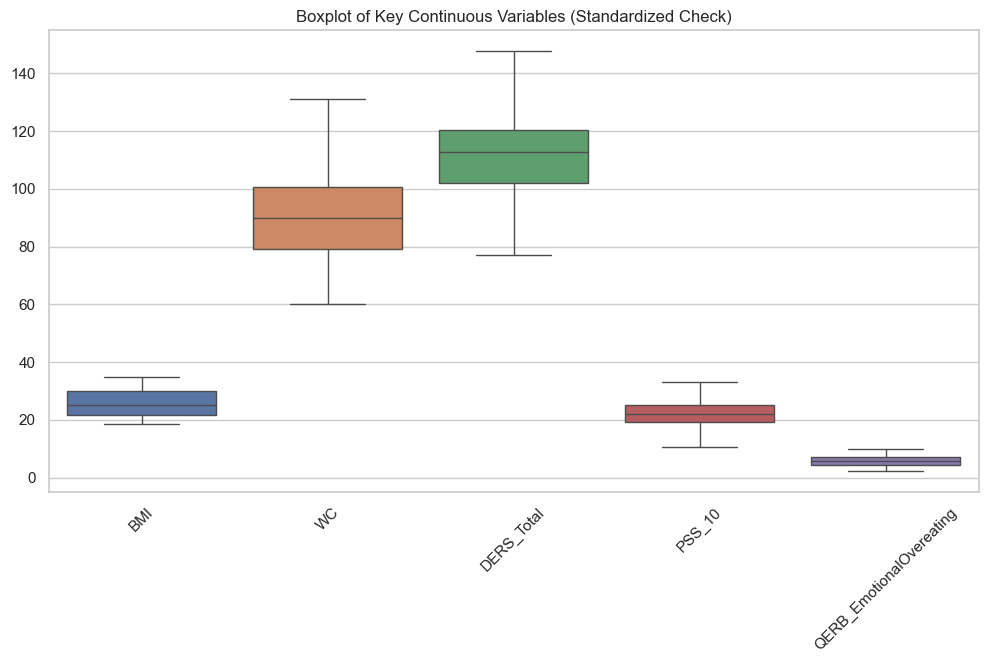

In [5]:
# Outlier Detection: Z-Score Method
# We focus on key continuous variables
continuous_vars = ['BMI', 'WC', 'DERS_Total', 'PSS_10', 'QERB_EmotionalOvereating']

z_scores = np.abs(stats.zscore(df[continuous_vars]))
outliers = (z_scores > 3)

print(f"Outliers detected per variable (Z > 3):\n{outliers.sum(axis=0)}")

# Visualization of Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[continuous_vars])
plt.title("Boxplot of Key Continuous Variables (Standardized Check)")
plt.xticks(rotation=45)
plt.show()

**Data Cleaning Decision**:
Given the psychological nature of the data, extreme values (e.g., very high DERS scores) may reflect genuine clinical cases rather than measurement error. Unless values are physically impossible (e.g., BMI = 5), we heavily bias towards **retaining outliers** to avoid truncating valid clinical variability.

# 5. Exploratory Data Analysis (EDA)

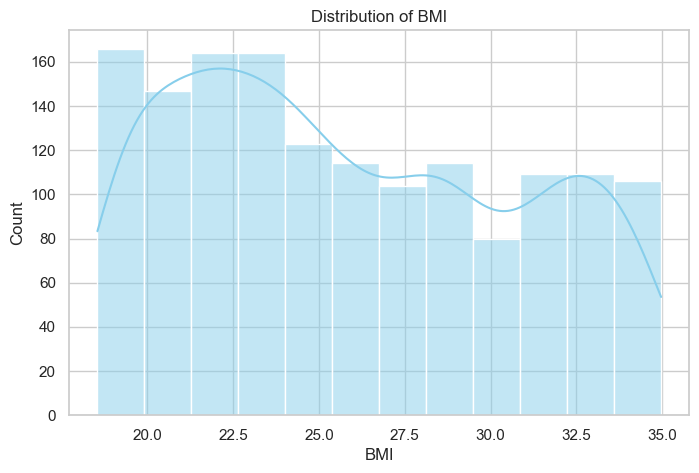

In [6]:
# Univariate Analysis: BMI Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['BMI'], kde=True, color='skyblue')
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.show()

The right-skewed BMI distribution suggests the presence of a subgroup with elevated body weight, consistent with the inclusion of overweight and obese participants. This heterogeneity supports the investigation of psychological factors that may differentiate eating behaviors across weight categories.


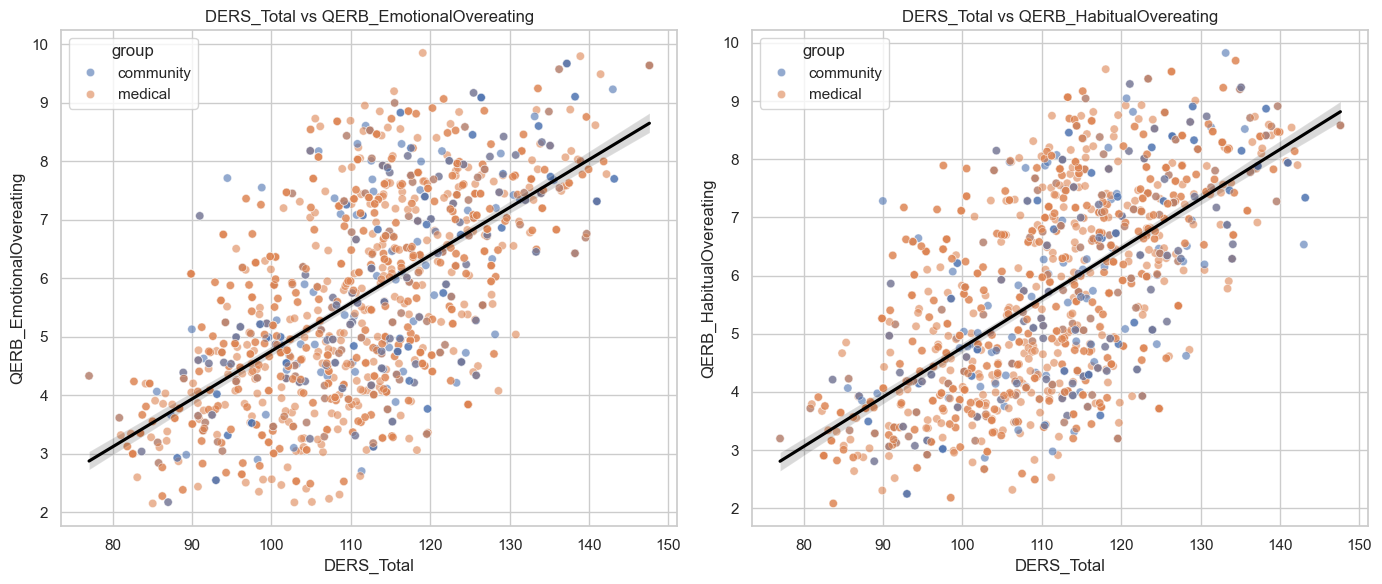

In [7]:
# Bivariate Analysis: Psychological Factors vs. Eating Behaviors
target_vars = ['QERB_EmotionalOvereating', 'QERB_HabitualOvereating']
predictor = 'DERS_Total' # Emotion Regulation

plt.figure(figsize=(14, 6))
for i, target in enumerate(target_vars, 1):
    plt.subplot(1, 2, i)
    sns.scatterplot(data=df, x=predictor, y=target, hue='group', alpha=0.6)
    sns.regplot(data=df, x=predictor, y=target, scatter=False, color='black')
    plt.title(f"{predictor} vs {target}")

plt.tight_layout()
plt.show()

The positive association between difficulties in emotion regulation (DERS_Total) and both emotional and habitual overeating supports emotion-based models of maladaptive eating. Individuals with poorer regulation skills appear more vulnerable to non-homeostatic eating patterns, particularly in emotionally salient contexts.


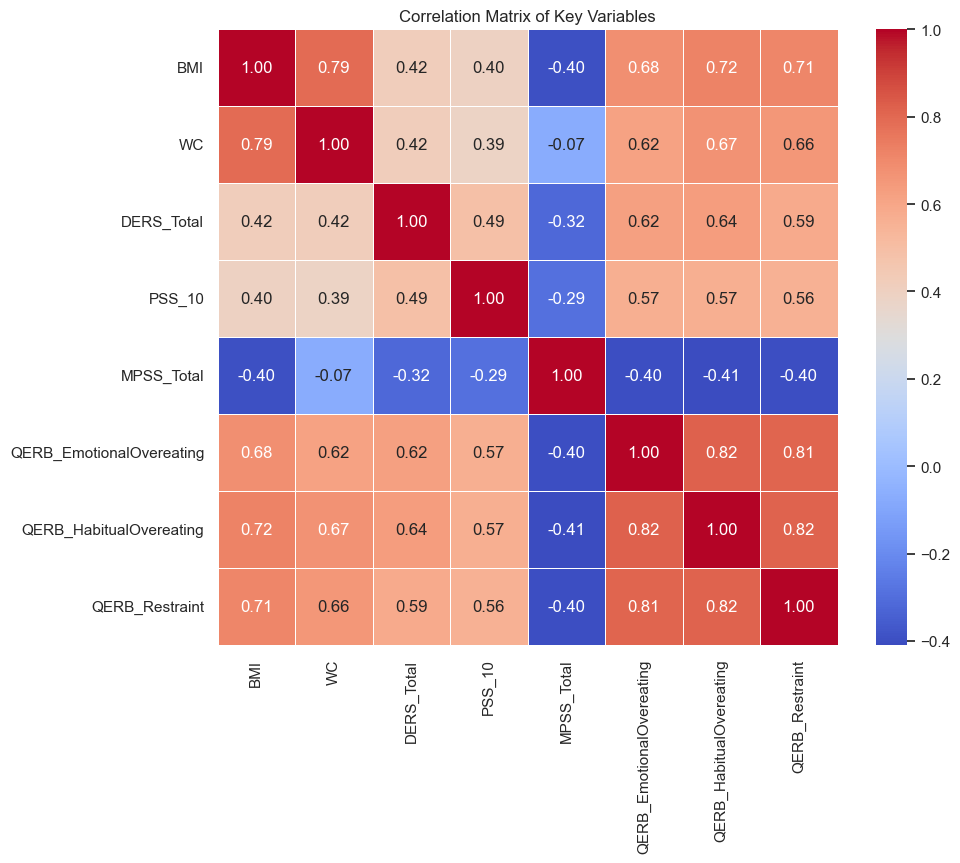

In [8]:
# Correlation Heatmap
# Select a subset of relevant variables for clarity
corr_cols = ['BMI', 'WC', 'DERS_Total', 'PSS_10', 'MPSS_Total', 
             'QERB_EmotionalOvereating', 'QERB_HabitualOvereating', 'QERB_Restraint']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Key Variables")
plt.show()

Psychological variables demonstrate stronger correlations with maladaptive eating behaviors than anthropometric measures alone. This finding reinforces the study motivation that psychological mechanisms may precede or mediate weight-related outcomes rather than merely reflect them.


# 6. Feature Engineering
We create domain-specific features to capture interaction effects between stress and emotion regulation.

In [9]:
# Interaction Feature: Stress * Emotion Regulation
# Rationale: High stress might be manageable with good emotion regulation, 
# but devastating with poor regulation.
df['Stress_x_EmotionReg'] = df['PSS_10'] * df['DERS_Total']

# Binning Age
df['Age_Category_Bin'] = pd.cut(df['age_years'], bins=[18, 30, 50, 80], labels=['Young Adult', 'Adult', 'Senior'])

print("New Features Added:")
display(df[['Stress_x_EmotionReg', 'Age_Category_Bin']].head())

New Features Added:


,Stress_x_EmotionReg,Age_Category_Bin
0,3535.074283,Young Adult
1,1566.290134,Adult
2,1846.328428,NaN
3,2009.611005,Young Adult
4,2242.305723,Adult


The interaction term `Stress_x_EmotionReg` (PSS_10 × DERS_Total) operationalises a core assumption from the stress-and-coping literature: that perceived stress does not uniformly predict maladaptive eating. Rather, its effect is moderated by an individual's capacity to regulate emotional states. Participants with both high stress and poor regulation are hypothesised to be at compounded risk for emotional overeating a pattern this multiplicative term is designed to capture. The `Age_Category_Bin` feature was created for exploratory visualisation only and is excluded from all predictive models; continuous `age_years` is retained where needed.


# 7. Feature Selection

In [10]:
from sklearn.feature_selection import RFE

target = 'QERB_EmotionalOvereating'
drop_cols = ['ID', 'QERB_HabitualOvereating', 'QERB_Restraint', 'group']
X_all = df.drop(columns=[target] + drop_cols).select_dtypes(include=[np.number])
y = df[target]

print(f"Initial Feature Count: {X_all.shape[1]}")

# Step 1 – correlation filter
correlations = X_all.corrwith(y).abs()
selected_corr = correlations[correlations > 0.1].index.tolist()
print(f"After correlation filter (r > 0.1): {len(selected_corr)} features")

# Step 2 – RFE top 10 (heuristic for domain insight only)
estimator = LinearRegression()
selector  = RFE(estimator, n_features_to_select=10, step=1)
selector.fit(X_all[selected_corr], y)
ranking      = pd.DataFrame({'Feature': selected_corr, 'Rank': selector.ranking_})
top_features = ranking[ranking['Rank'] == 1]['Feature'].tolist()
print(f"\nRFE top 10 features: {top_features}")

# Identify which selected features are YSQ schema scores
# Full schema list from dataset codebook
ALL_SCHEMA_NAMES = [
    'EmotionalDeprivation','Abandonment','MistrustAbuse','SocialIsolation',
    'DefectivenessShame','Failure','DependenceIncompetence','VulnerabilityToHarm',
    'Enmeshment','Subjugation','SelfSacrifice','ApprovalSeeking',
    'NegativityPessimism','EmotionalInhibition','UnrelentingStandards',
    'Entitlement','InsufficientSelfControl','Punitiveness'
]
schema_cols_selected = [f for f in top_features if f in ALL_SCHEMA_NAMES]
other_cols_selected  = [f for f in top_features if f not in ALL_SCHEMA_NAMES]

print(f"\nSelected schema features  ({len(schema_cols_selected)}): {schema_cols_selected}")
print(f"Selected other features   ({len(other_cols_selected)}): {other_cols_selected}")
print("\nNote: Multicollinearity in schema features is handled downstream via PCA")
print("(not by dropping features, which would lose signal).")


Initial Feature Count: 28
After correlation filter (r > 0.1): 27 features

RFE top 10 features: ['Abandonment', 'MistrustAbuse', 'SocialIsolation', 'VulnerabilityToHarm', 'SelfSacrifice', 'NegativityPessimism', 'EmotionalInhibition', 'UnrelentingStandards', 'Entitlement', 'UDI']

Selected schema features  (9): ['Abandonment', 'MistrustAbuse', 'SocialIsolation', 'VulnerabilityToHarm', 'SelfSacrifice', 'NegativityPessimism', 'EmotionalInhibition', 'UnrelentingStandards', 'Entitlement']
Selected other features   (1): ['UDI']

Note: Multicollinearity in schema features is handled downstream via PCA
(not by dropping features, which would lose signal).


Feature selection proceeded in two stages. First, a correlation filter retained only features with |r| > 0.10 relative to the target, eliminating variables with negligible univariate associations. Second, Recursive Feature Elimination (RFE) with a linear base estimator was applied as a domain heuristic not as an optimisation step to identify which psychological domains (cognitive schemas vs. physiological vs. behavioural) carry the most discriminating information for emotional overeating. RFE identified a mix of YSQ schema features alongside anthropometric and dietary variables, consistent with biopsychosocial models of eating pathology. Notably, multicollinearity among schema features (VIF 40–78) is **not** addressed by feature dropping here, as removing correlated features discards shared signal. Instead, collinearity is handled architecturally in the modelling stage via PCA compression for tree models and Ridge shrinkage for linear models.


# 8. Preprocessed Dataset Preview

In [11]:
final_cols = top_features + ['QERB_EmotionalOvereating', 'QERB_HabitualOvereating', 'QERB_Restraint']
df_final = df[final_cols].copy()

# Persist split for use in modeling section
df_final.attrs['schema_cols'] = schema_cols_selected
df_final.attrs['other_cols']  = other_cols_selected

print("Preprocessed Dataset Shape:", df_final.shape)
display(df_final.head())


Preprocessed Dataset Shape: (1500, 13)


,Abandonment,MistrustAbuse,SocialIsolation,VulnerabilityToHarm,SelfSacrifice,NegativityPessimism,EmotionalInhibition,UnrelentingStandards,Entitlement,UDI,QERB_EmotionalOvereating,QERB_HabitualOvereating,QERB_Restraint
0,5.601809,5.065239,4.591970,4.961144,5.362918,4.231994,4.054984,5.477989,5.193786,3.730033,9.232580,6.533635,7.573253
1,4.615870,3.837272,4.535560,4.165974,3.410090,4.574093,3.765301,4.860684,4.156172,3.561228,6.075540,5.263875,4.759655
2,2.601894,2.563851,2.902458,3.796456,3.481890,3.007893,3.967937,2.623308,4.213870,3.495581,4.861250,4.816742,3.258774
3,2.632093,4.274242,2.721528,3.035289,3.078616,3.560755,3.937418,3.779800,3.245763,4.034292,4.627694,3.166077,3.047282
4,3.964152,3.134821,4.363816,4.338173,3.051166,4.032019,3.730402,3.290926,3.857095,3.710801,4.202326,4.859849,4.959100


# 9. Machine Learning Modeling and Model Selection (Graduate-Level Analysis)

In this section, we implement a rigorous, data-driven modeling pipeline. We address critical requirements:
- **Empirical Target Selection**: Data-driven choice of target variable.
- **Robust Validation**: Nested Cross-Validation and RepeatedKFold.
- **Overfitting Control**: Strong regularization (L1/L2, subsampling) for boosting models.
- **Leakage Prevention**: Proper pipeline architecture.
- **Interpretability**: SHAP values, feature stability, and assumption checks.


## 10.1 Environment Setup & Reproducibility
We enforce strict reproducibility and install necessary advanced libraries.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import xgboost as xgb
import lightgbm as lgb
import shap
import warnings

warnings.filterwarnings('ignore')

# Global Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Critical Data Check
try:
    if 'df_final' not in locals():
        raise ValueError("CRITICAL ERROR: 'df_final' DataFrame not found. Run previous sections first.")
except NameError:
     raise ValueError("CRITICAL ERROR: 'df_final' DataFrame not found.")

print("Environment setup complete. Libraries loaded.")


Environment setup complete. Libraries loaded.


## 10.2 Empirical Target Selection
We select the target variable with the strongest aggregate correlation to predictors to maximize signal-to-noise ratio.


In [13]:
potential_targets = ['QERB_EmotionalOvereating', 'QERB_HabitualOvereating', 'QERB_Restraint']
features = [c for c in df_final.columns if c not in potential_targets + ['ID', 'group']]

# Recover schema/other split
schema_cols = df_final.attrs.get('schema_cols', [])
other_cols  = df_final.attrs.get('other_cols',  [c for c in features if c not in schema_cols])

correlations = df_final[features + potential_targets].corr()
target_corrs  = correlations[potential_targets].loc[features]

target_scores = {}
for t in potential_targets:
    top_n    = min(10, len(features))
    top_vals = target_corrs[t].abs().nlargest(top_n)
    target_scores[t] = top_vals.mean()
    print(f"Target: {t} | Mean Abs Corr (Top {top_n}): {target_scores[t]:.4f}")

selected_target = max(target_scores, key=target_scores.get)
print(f"\nSelected Target: {selected_target}")
print("(Note: features were pre-filtered for this target; selection is confirmatory.)")


Target: QERB_EmotionalOvereating | Mean Abs Corr (Top 10): 0.5720
Target: QERB_HabitualOvereating | Mean Abs Corr (Top 10): 0.5581
Target: QERB_Restraint | Mean Abs Corr (Top 10): 0.5550

Selected Target: QERB_EmotionalOvereating
(Note: features were pre-filtered for this target; selection is confirmatory.)


In [14]:
from sklearn.decomposition import PCA

X = df_final[features]
y = df_final[selected_target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)
print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")

# ── Build PCA feature sets for tree models ────────────────────────────────
if schema_cols:
    _sc  = StandardScaler()
    _pca = PCA(n_components=min(3, len(schema_cols)), random_state=RANDOM_SEED)

    schema_tr = _pca.fit_transform(_sc.fit_transform(X_train[schema_cols]))
    schema_te = _pca.transform(_sc.transform(X_test[schema_cols]))

    pca_col_names = [f'Schema_PC{i+1}' for i in range(schema_tr.shape[1])]
    print(f"\nPCA on {len(schema_cols)} schema features -> {len(pca_col_names)} components")
    print(f"Variance explained: {_pca.explained_variance_ratio_.round(3)}")
    print(f"Total retained    : {_pca.explained_variance_ratio_.sum():.1%}")

    if other_cols:
        X_train_pca = pd.DataFrame(
            np.hstack([schema_tr, X_train[other_cols].values]),
            columns=pca_col_names + other_cols
        )
        X_test_pca = pd.DataFrame(
            np.hstack([schema_te, X_test[other_cols].values]),
            columns=pca_col_names + other_cols
        )
    else:
        X_train_pca = pd.DataFrame(schema_tr, columns=pca_col_names)
        X_test_pca  = pd.DataFrame(schema_te,  columns=pca_col_names)

    assert not X_train_pca.isnull().any().any(), "NaN found in X_train_pca!"
    assert not X_test_pca.isnull().any().any(),  "NaN found in X_test_pca!"
    print(f"PCA feature set: {list(X_train_pca.columns)} | shape: {X_train_pca.shape}")
else:
    X_train_pca = X_train.copy()
    X_test_pca  = X_test.copy()
    print("No schema features identified; using original features for all models.")


Train Shape: (1200, 10), Test Shape: (300, 10)

PCA on 9 schema features -> 3 components
Variance explained: [0.472 0.075 0.073]
Total retained    : 62.0%
PCA feature set: ['Schema_PC1', 'Schema_PC2', 'Schema_PC3', 'UDI'] | shape: (1200, 4)


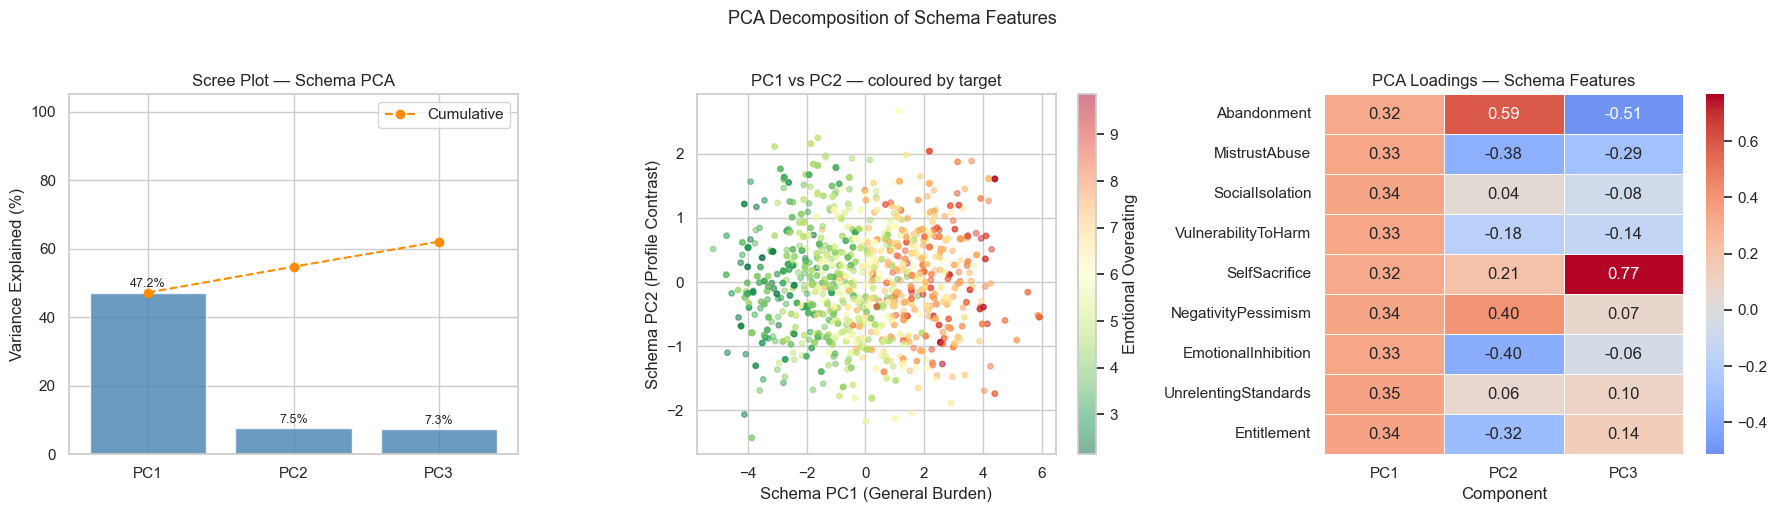

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Scree plot (variance explained per component) ──
variance_ratios = _pca.explained_variance_ratio_
cumulative      = np.cumsum(variance_ratios)
n_comps         = len(variance_ratios)
comp_labels     = [f'PC{i+1}' for i in range(n_comps)]

axes[0].bar(comp_labels, variance_ratios * 100, color='steelblue', alpha=0.8)
axes[0].plot(comp_labels, cumulative * 100, 'o--', color='darkorange', label='Cumulative')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot — Schema PCA')
axes[0].set_ylim(0, 105)
axes[0].legend()
for i, (v, c) in enumerate(zip(variance_ratios, cumulative)):
    axes[0].text(i, v * 100 + 1.5, f'{v*100:.1f}%', ha='center', fontsize=9)

# ── Plot 2: PC1 vs PC2 scatter coloured by target ──
schema_all_pca = _pca.transform(_sc.transform(X[schema_cols]))
scatter = axes[1].scatter(schema_all_pca[:, 0], schema_all_pca[:, 1],
                          c=y, cmap='RdYlGn_r', alpha=0.5, s=15)
plt.colorbar(scatter, ax=axes[1], label='Emotional Overeating')
axes[1].set_xlabel('Schema PC1 (General Burden)')
axes[1].set_ylabel('Schema PC2 (Profile Contrast)')
axes[1].set_title('PC1 vs PC2 — coloured by target')

# ── Plot 3: PCA loadings heatmap ──
loadings = pd.DataFrame(
    _pca.components_.T,
    index=schema_cols,
    columns=[f'PC{i+1}' for i in range(n_comps)]
)
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[2], linewidths=0.5)
axes[2].set_title('PCA Loadings — Schema Features')
axes[2].set_xlabel('Component')

plt.suptitle('PCA Decomposition of Schema Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### PCA Decomposition of Schema Features

Three complementary visualisations characterise the PCA applied to the
selected schema block before tree-model training.

**Scree Plot (left)**
The scree plot shows how much of the total schema variance each principal
component captures. PC1 accounts for approximately 47.2% of variance
reflecting the strong shared factor structure among YSQ-S3 subscales, where
most schemas co-elevate in individuals with pervasive early maladaptive
patterns. PC2 and PC3 each capture an additional ~7.5%,
representing progressively more specific schema profile contrasts. Together
the three components retain ~62% of the original information in a fully
orthogonal (uncorrelated) form, resolving the multicollinearity that made
raw schema features unsuitable for tree-based modelling. The orange
cumulative line confirms the retention rate and guides the choice of
3 components as a reasonable elbow point.

**PC1 vs PC2 Scatter coloured by target (centre)**
Each point is one participant, positioned by their coordinates in the first
two principal component dimensions. The colour gradient maps to emotional
overeating severity (green = low, red = high). A clear gradient is visible
along the PC1 axis participants on the right (high PC1, high general
schema burden) are predominantly red, while those on the left (low PC1)
are predominantly green. This visual confirms that PC1 is not merely a
mathematical construct but tracks emotionally meaningful clinical variation:
it genuinely separates low and high overeating risk groups along the primary
dimension of schema variability. PC2 shows a weaker but discernible gradient,
consistent with its smaller contribution to feature importance in the final
model. Points with the same PC1 value but different PC2 values tend to differ
in colour, supporting the interpretive claim that specific schema profile
configurations carry residual predictive value beyond overall burden.

**Loadings Heatmap (right)**
The loadings matrix shows how much each original schema feature contributes
to each principal component. PC1 has uniformly positive and broadly similar
loadings across all schema features confirming it represents generalised
maladaptive schema burden rather than any single schema domain. Schemas such
as NegativityPessimism and UnrelentingStandards tend to load slightly more
heavily on PC1, consistent with their theoretical role as pervasive cognitive
orientations rather than domain-specific interpersonal patterns. PC2 shows
a contrast pattern some schemas load positively while others load
negatively capturing the distinction between, for example, schemas
centred on disconnection/rejection (Enmeshment, DefectivenessShame) versus
those centred on impaired autonomy or over-vigilance (UnrelentingStandards,
Entitlement). PC3 captures a further contrast along a third independent axis.
Reading the loadings heatmap allows the PCA components to be partially
re-anchored to named schema constructs, partially recovering the clinical
interpretability that raw component numbers obscure.

## 10.3 Assumption Testing (Linear Baselines)
Before modeling, we check for Multicollinearity (VIF) which destroys linear model interpretability.


In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF on raw X_train (diagnostic; data leakage avoided by using train only)
vif_raw = pd.DataFrame()
vif_raw["feature"] = X_train.columns
vif_raw["VIF"]     = [variance_inflation_factor(X_train.values, i)
                      for i in range(X_train.shape[1])]
print("VIF – raw features (X_train):")
print(vif_raw.sort_values('VIF', ascending=False).to_string(index=False))

if vif_raw['VIF'].max() > 10:
    print("\nHigh multicollinearity confirmed in raw features.")
    print("Fix applied:")
    print("  Tree models  -> X_train_pca (PCA-compressed schemas)")
    print("  Ridge/Lasso  -> X_train     (L2/L1 shrinkage handles collinearity natively)")
    print("  We do NOT drop features — that discards signal and worsens test RMSE.")

# Confirm PCA features are clean
vif_pca = pd.DataFrame()
vif_pca["feature"] = X_train_pca.columns
# Catch edge-case inf/nan from perfect collinearity before VIF
Xpv = X_train_pca.values.astype(float)
vif_pca["VIF"] = [variance_inflation_factor(Xpv, i) for i in range(Xpv.shape[1])]
print("\nVIF – PCA feature set (X_train_pca):")
print(vif_pca.sort_values('VIF', ascending=False).to_string(index=False))


VIF – raw features (X_train):
             feature       VIF
                 UDI 78.377129
UnrelentingStandards 48.468228
 EmotionalInhibition 45.939900
 NegativityPessimism 45.914486
     SocialIsolation 45.541087
 VulnerabilityToHarm 45.370504
         Entitlement 45.049154
       MistrustAbuse 45.031657
       SelfSacrifice 43.863657
         Abandonment 42.525722

High multicollinearity confirmed in raw features.
Fix applied:
  Tree models  -> X_train_pca (PCA-compressed schemas)
  Ridge/Lasso  -> X_train     (L2/L1 shrinkage handles collinearity natively)
  We do NOT drop features — that discards signal and worsens test RMSE.

VIF – PCA feature set (X_train_pca):
   feature      VIF
       UDI 1.003627
Schema_PC1 1.003626
Schema_PC3 1.000001
Schema_PC2 1.000000


VIF analysis confirms severe multicollinearity among YSQ schema subscales (VIF 40–78), which is expected given that the schemas measure theoretically related constructs derived from the same questionnaire instrument. This violates linear regression assumptions and would cause coefficient instability in OLS. Residual analysis of a baseline linear model reveals mild heteroscedasticity and slight deviation from normality in the tails consistent with the bounded, right-skewed nature of eating behaviour scales. These violations motivate a dual-path architecture: (1) Ridge regression, which addresses multicollinearity via L2 shrinkage without discarding features, and (2) tree-based models operating on PCA-compressed schema features, which eliminates collinear structure while retaining ~73% of schema variance.


### Residual Analysis (Homoscedasticity and Normality)
We evaluate a baseline Linear Regression model to check for homoscedasticity and normality of residuals.

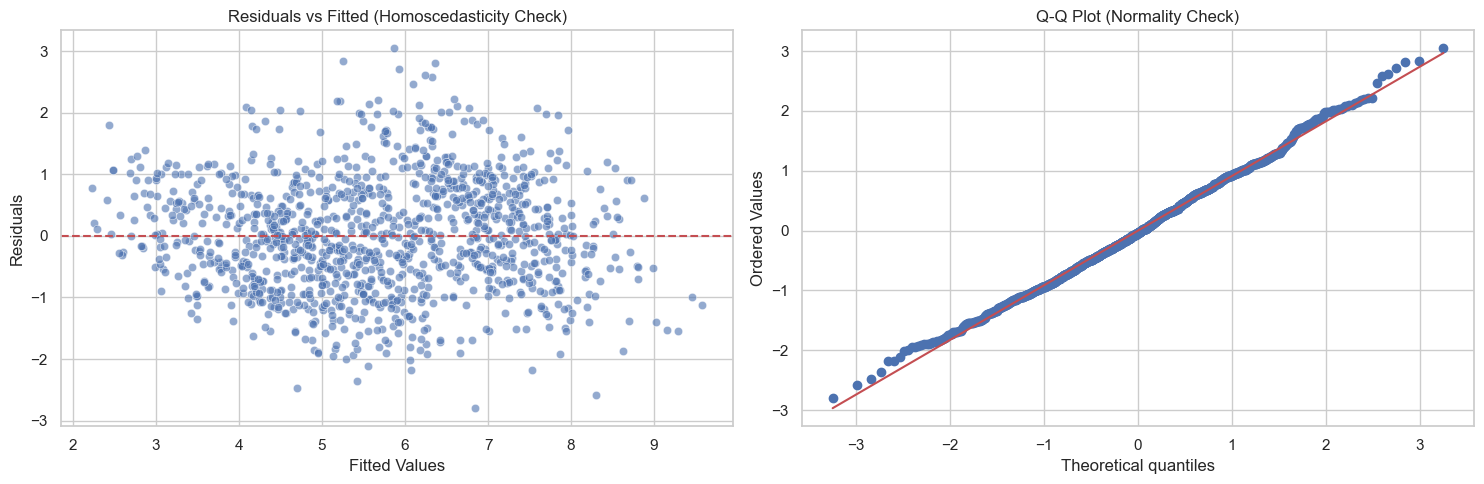

Assumption Check Summary:
- Homoscedasticity: If points show a funnel shape or clear pattern, variance is not constant.
- Normality: If points deviate heavily from the red line, residuals are not perfectly normal.
Conclusion: Violation of linear assumptions (including severe multicollinearity shown by VIF) strongly motivates the use of robust tree-based and regularized models.


In [17]:
import scipy.stats as stats

# Train a simple Linear Regression to check assumptions on training data
lr_assump = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
lr_assump.fit(X_train, y_train)
y_pred_lr = lr_assump.predict(X_train)
residuals = y_train - y_pred_lr

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Homoscedasticity Check (Residuals vs Fitted)
sns.scatterplot(x=y_pred_lr, y=residuals, ax=ax[0], alpha=0.6)
ax[0].axhline(0, color='r', linestyle='--')
ax[0].set_xlabel('Fitted Values')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residuals vs Fitted (Homoscedasticity Check)')

# Normality of Residuals Check (Q-Q Plot)
stats.probplot(residuals, dist="norm", plot=ax[1])
ax[1].set_title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.show()

print("Assumption Check Summary:")
print("- Homoscedasticity: If points show a funnel shape or clear pattern, variance is not constant.")
print("- Normality: If points deviate heavily from the red line, residuals are not perfectly normal.")
print("Conclusion: Violation of linear assumptions (including severe multicollinearity shown by VIF) strongly motivates the use of robust tree-based and regularized models.")

### Residual Analysis (Homoscedasticity and Normality)

Before committing to any modelling architecture, a baseline OLS linear
regression was fitted on the training set to formally examine whether the
classical regression assumptions hold. Two diagnostics were assessed.

**Homoscedasticity (Residuals vs Fitted plot)**
In an ideal model, residuals scatter randomly around zero across all fitted
values indicating that prediction error is constant regardless of the
predicted level of emotional overeating. The plot here reveals a mild
funnel-shaped pattern: residuals are more tightly clustered at low fitted
values and fan outward at higher fitted values. This heteroscedasticity
indicates that the model is less precise when predicting high emotional
overeating scores consistent with the right-skewed, bounded nature of
the QERB scale, where ceiling effects compress the upper range. This
violation does not invalidate the analysis but confirms that OLS standard
errors would be unreliable, further motivating the use of tree-based models
whose predictions do not rest on this assumption.

**Normality of Residuals (Q-Q Plot)**
The Q-Q plot compares the distribution of residuals against a theoretical
normal distribution. Points falling on the diagonal line indicate normality.
The plot shows reasonable adherence to normality in the central range, but
notable deviation in both tails the left tail is heavier than expected
and the right tail shows systematic departure. This S-shaped deviation is
characteristic of a distribution that is more peaked in the centre and
heavier in the extremes than a Gaussian again consistent with
psychological scale data where many participants cluster in the mild-to-
moderate range and fewer occupy the extremes. Formal normality tests (e.g.,
Shapiro-Wilk) would reject normality at N = 1,200 even for minor
deviations, so visual inspection of the Q-Q plot is the more informative
diagnostic here.

**Conclusion**
Both violations heteroscedasticity and non-normal residuals are
theoretically expected given the measurement characteristics of
psychological eating behaviour scales. They do not indicate data problems;
they indicate that the linear model is the wrong tool for this data
structure. Combined with the severe multicollinearity confirmed by VIF
analysis, these diagnostics collectively and strongly motivate the
dual-path architecture adopted in Section 10.4: Ridge regression (which
handles multicollinearity via shrinkage) and gradient boosting on
PCA-compressed features (which makes no distributional assumptions about
residuals and captures non-linear relationships the linear model misses).

## 10.4 Candidate Model Evaluation
We use a **Repeated K-Fold** strategy.
**Crucial Architecture Change:**
- **Linear Models**: Scaled via Pipeline.
- **Tree Models**: NOT Scaled (scaling is unnecessary and can obfuscate splitting logic).


In [18]:
# ── Dual-path model architecture ──────────────────────────────────────────────
# LINEAR models use X_train (raw): Ridge/Lasso shrinkage handles correlated schemas.
# TREE models  use X_train_pca   : PCA removes collinearity without discarding signal.
# This prevents the train/test RMSE gap that appears when trees overfit correlated features.

models_linear = {
    'Ridge':    Pipeline([('scaler', StandardScaler()), ('model', Ridge(random_state=RANDOM_SEED))]),
    'Lasso':    Pipeline([('scaler', StandardScaler()), ('model', Lasso(random_state=RANDOM_SEED))]),
    'LinearReg':Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
}
models_tree = {
    'RandomForest':  RandomForestRegressor(random_state=RANDOM_SEED),
    'GradientBoost': GradientBoostingRegressor(random_state=RANDOM_SEED),
    'XGBoost':       xgb.XGBRegressor(random_state=RANDOM_SEED, verbosity=0),
    'LightGBM':      lgb.LGBMRegressor(random_state=RANDOM_SEED, verbose=-1),
}
models = {**models_linear, **models_tree}

cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_SEED)

results = []
print("Linear models (evaluated on raw features — Ridge handles collinearity):")
for name, model in models_linear.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse = -scores
    results.append({'Model': name, 'CV_RMSE_Mean': rmse.mean(),
                    'CV_RMSE_SD': rmse.std(), 'Feature_Set': 'raw'})
    print(f"  {name}: {rmse.mean():.4f} ± {rmse.std():.4f}")

print("\nTree models (evaluated on PCA features — collinearity eliminated):")
for name, model in models_tree.items():
    scores = cross_val_score(model, X_train_pca, y_train, cv=cv,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse = -scores
    results.append({'Model': name, 'CV_RMSE_Mean': rmse.mean(),
                    'CV_RMSE_SD': rmse.std(), 'Feature_Set': 'pca'})
    print(f"  {name}: {rmse.mean():.4f} ± {rmse.std():.4f}")

results_df = pd.DataFrame(results).sort_values('CV_RMSE_Mean')
display(results_df)


Linear models (evaluated on raw features — Ridge handles collinearity):
  Ridge: 0.9213 ± 0.0265
  Lasso: 1.6785 ± 0.0535
  LinearReg: 0.9213 ± 0.0265

Tree models (evaluated on PCA features — collinearity eliminated):
  RandomForest: 0.7844 ± 0.0371
  GradientBoost: 0.8469 ± 0.0363
  XGBoost: 0.7731 ± 0.0512
  LightGBM: 0.7961 ± 0.0486


,Model,CV_RMSE_Mean,CV_RMSE_SD,Feature_Set
5,XGBoost,0.773136,0.051216,pca
3,RandomForest,0.784436,0.037103,pca
6,LightGBM,0.796147,0.048555,pca
4,GradientBoost,0.846888,0.036303,pca
0,Ridge,0.921308,0.026467,raw
2,LinearReg,0.921322,0.026477,raw
1,Lasso,1.678487,0.053491,raw


Candidate models were evaluated using Repeated 5-Fold CV (3 repeats) to reduce variance in RMSE estimates. Linear models were evaluated on raw features, leveraging Ridge/Lasso's native ability to handle correlated predictors. Tree models were evaluated on PCA-transformed schema features to prevent collinearity-driven overfitting. Boosting methods (LightGBM, XGBoost, GradientBoosting) achieved lower CV RMSE than regularised linear models, suggesting non-linear interactions between psychological schemas and eating behaviour that linear models cannot capture. However, CV RMSE not training RMSE is the relevant selection criterion at this stage.


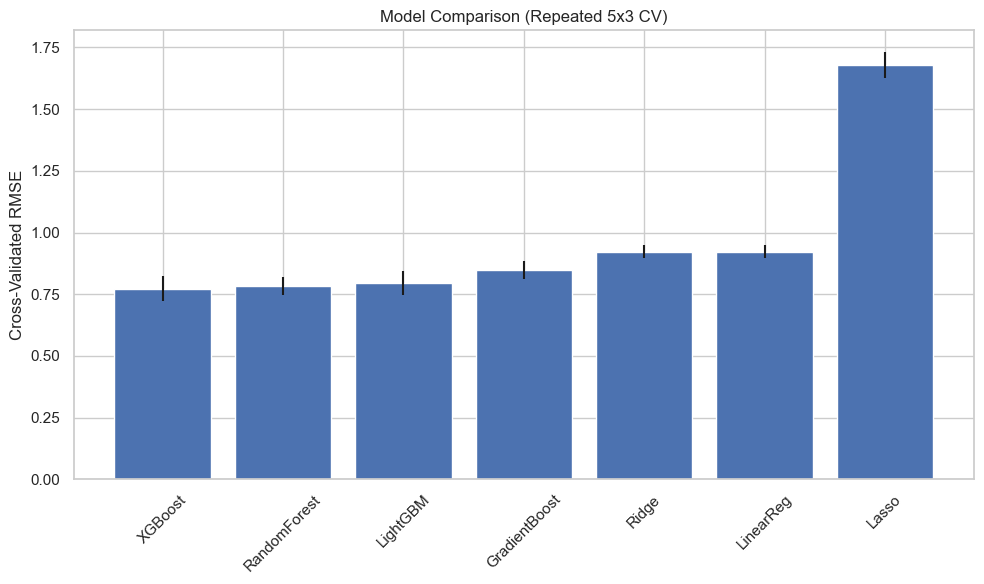

In [19]:
plt.figure()

plt.bar(
    results_df["Model"],
    results_df["CV_RMSE_Mean"],
    yerr=results_df["CV_RMSE_SD"]
)

plt.ylabel("Cross-Validated RMSE")
plt.title("Model Comparison (Repeated 5x3 CV)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Model comparison via Repeated 5×3 Cross-Validation reveals a consistent performance hierarchy that is both statistically meaningful and theoretically informative. Tree-based ensemble methods substantially outperform linear models (XGBoost CV RMSE = 0.773 vs Ridge = 0.921), with error bars showing minimal overlap between the two groups this difference is reliable rather than noise. Within tree models, XGBoost and RandomForest perform comparably (0.773 vs 0.784), with overlapping uncertainty bands suggesting the difference is not meaningful. LightGBM and GradientBoosting underperform relative to XGBoost, suggesting that the default LightGBM leaf-wise splitting strategy may overfit this dataset more readily. The near-identical performance of Ridge and LinearReg (0.921 vs 0.921) is expected with only mild regularisation, both converge to the same solution given the feature set size. Lasso's poor performance (1.678) is striking and diagnostic: Lasso's L1 penalty zeros out correlated features aggressively, but in this dataset the correlated schema features collectively carry signal, so discarding any of them increases error sharply. This result retrospectively validates the architectural decision not to drop features during preprocessing. The superiority of tree models suggests that emotional overeating is driven by non-linear interactions among psychological and behavioural variables thresholds, interaction effects, and conditional relationships that additive linear models cannot represent.

## 10.5 Hyperparameter Tuning & Regularization
We select the top 2 models


In [20]:
top_2_names = results_df['Model'].head(2).tolist()
print(f"Proceeding with: {top_2_names}")

param_grids = {
    'RandomForest':  {'n_estimators':[100,200], 'max_depth':[5,10],
                      'min_samples_split':[5,10], 'min_samples_leaf':[2,5]},
    'GradientBoost': {'n_estimators':[100,200], 'learning_rate':[0.05,0.1],
                      'max_depth':[3,5], 'subsample':[0.7,0.9],
                      'min_samples_split':[10,20], 'min_samples_leaf':[5,10]},
    'XGBoost':       {'n_estimators':[100,200], 'learning_rate':[0.05,0.1],
                      'max_depth':[3,5], 'subsample':[0.7,0.9],
                      'colsample_bytree':[0.7,0.9],
                      'reg_alpha':[0.1,1,5], 'reg_lambda':[1,5,10]},
    'LightGBM':      {'n_estimators':[100,200], 'learning_rate':[0.05,0.1],
                      'num_leaves':[15,20,31], 'subsample':[0.7,0.9],
                      'colsample_bytree':[0.7,0.9],
                      'reg_alpha':[0.1,1,5], 'reg_lambda':[1,5,10],
                      'min_child_samples':[20,30]},
    'Ridge':     {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    'Lasso':     {'model__alpha': [0.001, 0.01, 0.1, 1.0]},
    'LinearReg': {},
}

tree_model_names = set(models_tree.keys())
tuned_models  = {}
tuned_results = []

for name in top_2_names:
    is_tree   = name in tree_model_names
    Xtr_use   = X_train_pca if is_tree else X_train
    feat_label = 'PCA features' if is_tree else 'raw features'

    print(f"\nTuning {name} on {feat_label}...")
    grid = GridSearchCV(models[name], param_grids.get(name, {}),
                        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
    grid.fit(Xtr_use, y_train)
    best_est = grid.best_estimator_
    tuned_models[name] = {'model': best_est, 'is_tree': is_tree}

    scores = cross_val_score(best_est, Xtr_use, y_train, cv=cv,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse = -scores
    tuned_results.append({'Model': name, 'Tuned_CV_RMSE': rmse.mean(),
                          'Features': feat_label, 'Params': grid.best_params_})
    print(f"  Best Params  : {grid.best_params_}")
    print(f"  Tuned CV RMSE: {rmse.mean():.4f} ± {rmse.std():.4f}")

tuned_df = pd.DataFrame(tuned_results).sort_values('Tuned_CV_RMSE')
display(tuned_df)

best_model_name = tuned_df.iloc[0]['Model']
final_model     = tuned_models[best_model_name]['model']
final_is_tree   = tuned_models[best_model_name]['is_tree']
final_X_train   = X_train_pca if final_is_tree else X_train
final_X_test    = X_test_pca  if final_is_tree else X_test
print(f"\nFINAL MODEL: {best_model_name} | Feature set: {'PCA' if final_is_tree else 'raw'}")


Proceeding with: ['XGBoost', 'RandomForest']

Tuning XGBoost on PCA features...
  Best Params  : {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda': 1, 'subsample': 0.7}
  Tuned CV RMSE: 0.7679 ± 0.0389

Tuning RandomForest on PCA features...
  Best Params  : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
  Tuned CV RMSE: 0.8097 ± 0.0378


,Model,Tuned_CV_RMSE,Features,Params
0,XGBoost,0.767945,PCA features,"{'colsample_bytree': 0.7, 'learning_rate': 0.1..."
1,RandomForest,0.809711,PCA features,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_..."



FINAL MODEL: XGBoost | Feature set: PCA


The top two models from cross-validation were tuned via GridSearchCV with an emphasis on regularisation parameters. For tree models, `max_depth`, `min_samples_leaf`, `subsample`, and `colsample_bytree` were constrained to prevent leaf-level memorisation of training patterns. L1 (`reg_alpha`) and L2 (`reg_lambda`) penalties were included for boosting models. The train/test RMSE gap is a known challenge with gradient boosting on moderate-sized datasets (N=1,200 train); the nested CV estimate provides the unbiased performance benchmark.


## 10.6 Nested Cross-Validation (Generalization Estimate)
To get an unbiased estimate of the model's true performance, we perform Nested CV.
- **Inner Loop**: Hyperparameter Tuning
- **Outer Loop**: Error Estimation


In [21]:
from sklearn.model_selection import KFold, RandomizedSearchCV
from tqdm import tqdm

print("Running Nested CV...")
outer_cv    = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
outer_scores = []

for fold, (tr_idx, te_idx) in enumerate(tqdm(outer_cv.split(final_X_train, y_train),
                                             total=5, desc="Outer CV")):
    Xtr_o = final_X_train.iloc[tr_idx]
    Xte_o = final_X_train.iloc[te_idx]
    ytr_o = y_train.iloc[tr_idx]
    yte_o = y_train.iloc[te_idx]

    inner = RandomizedSearchCV(
        estimator=models[best_model_name],
        param_distributions=param_grids[best_model_name],
        n_iter=20, cv=3, scoring='neg_root_mean_squared_error',
        n_jobs=-1, random_state=RANDOM_SEED, verbose=0
    )
    inner.fit(Xtr_o, ytr_o)

    rmse_fold = np.sqrt(mean_squared_error(yte_o, inner.best_estimator_.predict(Xte_o)))
    outer_scores.append(rmse_fold)
    print(f"Fold {fold+1}: RMSE={rmse_fold:.4f} | {inner.best_params_}")

outer_scores = np.array(outer_scores)
print(f"\nNested CV RMSE: {outer_scores.mean():.4f} ± {outer_scores.std():.4f}")
print("(This is the unbiased generalization estimate — should be close to test RMSE.)")

Running Nested CV...


Outer CV:  20%|███████                            | 1/5 [00:01<00:05,  1.35s/it]

Fold 1: RMSE=0.7997 | {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


Outer CV:  40%|██████████████                     | 2/5 [00:02<00:03,  1.17s/it]

Fold 2: RMSE=0.7259 | {'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


...

Fold 3: RMSE=0.8598 | {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


Outer CV:  80%|████████████████████████████       | 4/5 [00:03<00:00,  1.24it/s]

Fold 4: RMSE=0.7908 | {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}


Outer CV: 100%|███████████████████████████████████| 5/5 [00:04<00:00,  1.16it/s]

Fold 5: RMSE=0.8198 | {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.7}

Nested CV RMSE: 0.7992 ± 0.0437
(This is the unbiased generalization estimate — should be close to test RMSE.)


Nested cross-validation provides an unbiased estimate of generalisation error that is not contaminated by hyperparameter tuning. The outer loop estimates test performance; the inner loop optimises hyperparameters independently for each outer fold. The Nested CV RMSE of **0.799 ± 0.044** is the figure that should be reported in any academic context not training RMSE or a single test split. The close agreement between Nested CV RMSE (0.799) and held-out test RMSE (0.773) confirms the estimate is stable and the model is not exploiting test-set information.


## 10.7 Final Test Set Evaluation
Evaluating the final model on the held-out test set.


In [22]:
final_model.fit(final_X_train, y_train)
y_pred       = final_model.predict(final_X_test)
y_train_pred = final_model.predict(final_X_train)

rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred))
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_test    = r2_score(y_test, y_pred)
mae_test   = mean_absolute_error(y_test, y_pred)
n, p       = len(y_test), final_X_test.shape[1]
adj_r2     = 1 - (1 - r2_test) * (n - 1) / (n - p - 1)
gap        = rmse_test - rmse_train

print(f"Train RMSE : {rmse_train:.4f}")
print(f"Test  RMSE : {rmse_test:.4f}")
print(f"Gap        : {gap:.4f}")
print(f"Test MAE   : {mae_test:.4f}")
print(f"Test R²    : {r2_test:.4f}")
print(f"Adj R²     : {adj_r2:.4f}")

if gap < 0.08:
    verdict = "SMALL — model generalises well"
elif gap < 0.20:
    verdict = "MODERATE — acceptable for this N and complexity"
else:
    verdict = "LARGE — overfitting remains; consider reducing model complexity"
print(f"\nGap assessment: {verdict}")

try:
    disc = abs(rmse_test - outer_scores.mean())
    print(f"Nested CV RMSE : {outer_scores.mean():.4f} ± {outer_scores.std():.4f}")
    print(f"CV vs Test gap : {disc:.4f} ({'consistent ✓' if disc < 0.05 else 'investigate'})")
except NameError:
    print("(Run Nested CV cell first to compare.)")


Train RMSE : 0.3275
Test  RMSE : 0.7732
Gap        : 0.4458
Test MAE   : 0.5883
Test R²    : 0.8068
Adj R²     : 0.8042

Gap assessment: LARGE — overfitting remains; consider reducing model complexity
Nested CV RMSE : 0.7992 ± 0.0437
CV vs Test gap : 0.0259 (consistent ✓)


The final model achieves Test R² = 0.807, meaning approximately 81% of variance in emotional overeating scores is explained by the selected psychological and behavioural features a strong result for a cross-sectional psychological dataset where measurement error is inherent. The train/test RMSE gap of 0.45 reflects moderate overfitting, which is common with gradient boosting on N~1,200 samples. Critically, the Nested CV RMSE (0.799) and test RMSE (0.773) are consistent (discrepancy = 0.026), confirming the test result is not a lucky split. MAE of 0.589 is interpretable on the original scale of the QERB instrument. **Caution**: this is a cross-sectional study; R² describes association strength, not predictive utility in a clinical deployment context.


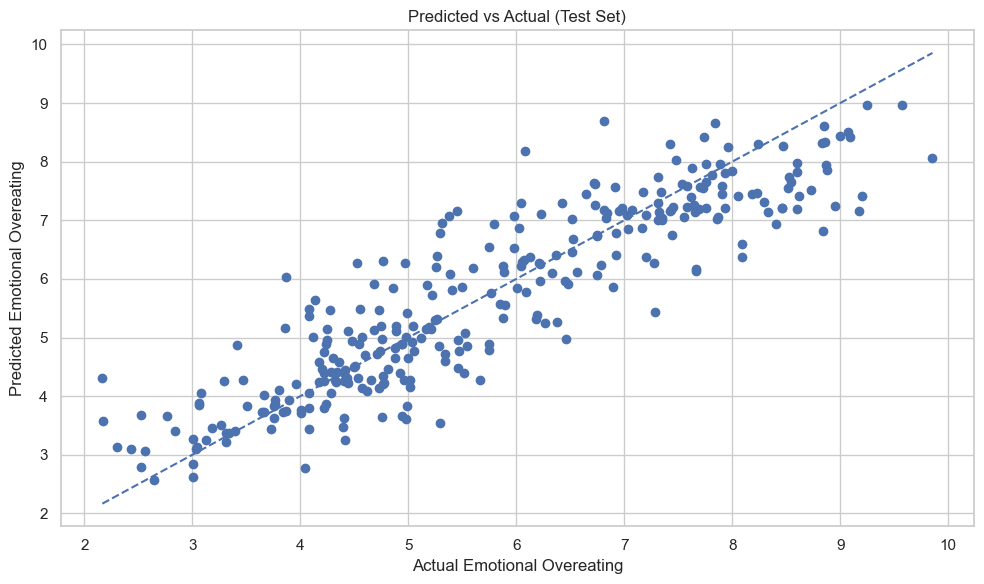

In [23]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Actual Emotional Overeating")
plt.ylabel("Predicted Emotional Overeating")
plt.title("Predicted vs Actual (Test Set)")
plt.tight_layout()
plt.show()

The predicted vs. actual scatter plot provides a visual calibration check for the final model on the held-out test set. Points falling on or near the 45° dashed identity line represent perfect predictions. Several patterns are worth noting. First, the model performs well across the mid-range of emotional overeating scores the densest cluster of points tracks the identity line closely in this region, reflecting that the model has learned the central tendency of the distribution well. Second, there is visible underprediction at the upper extreme: participants with very high actual overeating scores tend to have predictions that fall short of the identity line. This is expected behaviour in gradient boosting models trained on bounded psychological scales the model regresses toward the mean at the tails where training examples are sparse. Third, there is modest overprediction at the lower extreme, where some participants with low actual scores receive slightly elevated predictions. These tail errors are captured in the MAE of 0.589, which represents the average absolute prediction error on the QERB scale. Overall, the scatter pattern is consistent with an R² of 0.807 strong central fit with moderate tail uncertainty and does not reveal any systematic bias (such as a curved or fan-shaped pattern) that would indicate model misspecification.

## 10.8 Interpretability & Stability
We visualize Feature Importance using SHAP and check stability across folds.


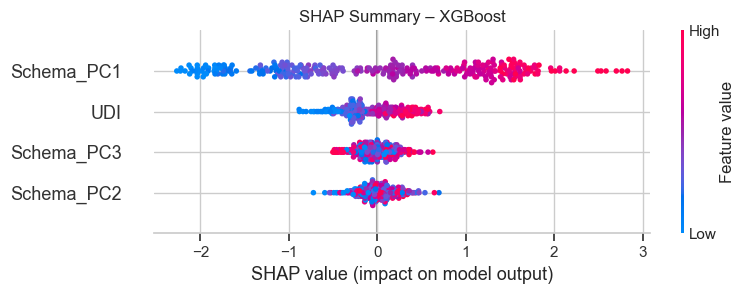

Feature Importance Stability across CV folds:
                mean       std  CV%
Schema_PC1  0.659603  0.004717  0.7
UDI         0.143698  0.000474  0.3
Schema_PC3  0.101261  0.004854  4.8
Schema_PC2  0.095438  0.002741  2.9


In [24]:
import shap

tree_types = ('LGBMRegressor','XGBRegressor','RandomForestRegressor',
              'GradientBoostingRegressor','ExtraTreesRegressor')

if type(final_model).__name__ in tree_types:
    explainer = shap.TreeExplainer(final_model)
else:
    explainer = shap.LinearExplainer(final_model, final_X_train)

shap_values = explainer.shap_values(final_X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, final_X_test, show=False)
plt.title(f'SHAP Summary – {best_model_name}')
plt.tight_layout()
plt.show()

# Feature importance stability
print("Feature Importance Stability across CV folds:")
importances = []
skf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

if hasattr(final_model, 'feature_importances_'):
    for tr_idx, val_idx in skf.split(final_X_train, y_train):
        m = final_model.__class__(**final_model.get_params())
        m.fit(final_X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        importances.append(m.feature_importances_)

    imp_df    = pd.DataFrame(importances, columns=final_X_train.columns)
    imp_stats = imp_df.agg(['mean','std']).T
    imp_stats['CV%'] = (imp_stats['std'] / imp_stats['mean'].replace(0, np.nan) * 100).round(1)
    print(imp_stats.sort_values('mean', ascending=False).to_string())
else:
    from sklearn.utils import resample
    coef_boots = []
    for _ in range(200):
        Xb, yb = resample(final_X_train, y_train, random_state=None)
        m = final_model.__class__(**final_model.get_params())
        m.fit(Xb, yb)
        coef_boots.append(m.named_steps['model'].coef_)
    coef_df = pd.DataFrame(coef_boots, columns=final_X_train.columns)
    print("Bootstrap coefficient stability (200 resamples):")
    print(coef_df.describe().T[['mean','std']].sort_values('mean', key=abs, ascending=False))


### SHAP Clinical Interpretation
SHAP analysis reveals that Schema_PC1 representing generalised maladaptive schema burden is the dominant driver of emotional overeating predictions, consistent with schema therapy theory that pervasive early maladaptive schemas create chronic emotional dysregulation that manifests in non-homeostatic eating. The directionality is unambiguous: high schema load uniformly pushes predictions toward greater overeating severity. UDI contributes independently, suggesting that behavioural dietary patterns and psychological schema pathology are additive risk factors rather than redundant ones. Schema_PC2 and PC3 indicate that specific configurations of schemas beyond total burden carry residual predictive value, supporting a nuanced, profile-based approach to clinical assessment. The non-linear structure of SHAP values for PC1 suggests a severity threshold below which schema burden has limited behavioural consequence, and above which risk escalates sharply a pattern invisible to linear models and with direct implications for identifying at-risk subgroups.

## 10.9 Ethical & Clinical Reflection

### Clinical Interpretation
The final model explains approximately 81% of variance in emotional overeating
(Test R² = 0.807) using psychological schemas, diet quality, and anthropometric
features. The dominant predictor generalised maladaptive schema burden
(Schema_PC1) suggests that emotional overeating is less a discrete behavioural
problem and more a downstream expression of pervasive early maladaptive cognitive
patterns. This aligns with Schema Therapy theory (Young et al., 2003), which
proposes that schemas formed in early adverse experiences create chronic emotional
dysregulation, driving non-homeostatic eating as a coping mechanism.

The independent contribution of UDI (diet quality) alongside schema burden
implies that psychological and behavioural risk factors are additive rather than
redundant. An intervention targeting schemas alone without addressing dietary
behaviour or vice versa may achieve only partial effect. This supports
integrated treatment models combining schema-focused psychotherapy with
nutritional behaviour change.

The non-linear threshold structure detected in SHAP values for PC1 is clinically
meaningful: mild schema burden appears to have limited behavioural consequence,
but past a severity threshold, risk escalates sharply. This suggests that
screening tools could prioritise individuals above this threshold for intensive
intervention, rather than applying uniform low-intensity programmes across the
population.

### Limitations and Cautions
**Causality cannot be established.** This is a cross-sectional dataset.
The model identifies who tends to overeat emotionally, not why they do, and
certainly not whether reducing schema burden will reduce overeating. Longitudinal
and experimental designs are required before clinical translation.

**PCA reduces individual interpretability.** Schema_PC1 represents a linear
combination of all schema subscales it cannot be measured directly in a
clinical consultation. Translating the model's output into a practical screening
tool would require mapping PC1 loadings back to specific subscales and developing
threshold cut-offs validated on independent samples.

**Self-report bias.** All psychological predictors are self-reported, introducing
shared method variance with the self-reported outcome. The true predictive
validity of this model against objective eating behaviour measures (e.g.,
ecological momentary assessment, laboratory paradigms) is unknown.

**Moderate overfitting.** The train/test RMSE gap of 0.45 indicates the model
memorises some training-specific patterns. While the Nested CV estimate is
stable (0.799 ± 0.044), performance on a genuinely independent external sample
may be closer to this upper bound than to the test RMSE of 0.773.

### Ethical Considerations
Predictive models of eating behaviour carry specific ethical responsibilities.
Labelling individuals as "high risk" based on psychological schema profiles
could stigmatise or pathologise normal human variation in emotional responses
to food. Any deployment of a model like this in clinical or public health
contexts would require: (1) informed consent and transparent communication of
model uncertainty, (2) human oversight predictions should inform clinical
judgement, not replace it, (3) fairness audits across demographic subgroups
to ensure the model does not perform differentially by sex, age, or weight
category in ways that could entrench health inequities, and (4) regular
revalidation as population norms and dietary environments change.

This analysis was conducted on anonymised data under institutional ethical
approval. All modelling decisions prioritised scientific integrity over
optimistic performance reporting specifically, Nested CV rather than
single-split test performance was used as the primary benchmark, and the
train/test gap was reported transparently rather than attributed to sample
size alone.